# Ejercicio 3: Problema del Subarreglo Máximo
## Implementación en Python — Fuerza Bruta vs Divide y Vencerás

### 1. Imports

Se importan las librerías necesarias para la generación de datos aleatorios, la medición del tiempo de ejecución y la visualización de los resultados.

In [1]:
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Algoritmo de Fuerza Bruta

Itera sobre todas las combinaciones posibles de subarreglos contiguos. Complejidad **O(n²)**.

In [2]:
def max_subarray_bruteforce(arr):
    max_sum = float('-inf')
    inicio = 0
    fin = 0

    for i in range(len(arr)):
        suma_actual = 0
        for j in range(i, len(arr)):
            suma_actual += arr[j]
            if suma_actual > max_sum:
                max_sum = suma_actual
                inicio = i
                fin = j

    return inicio, fin, max_sum

### 3. Algoritmo Divide y Vencerás

Divide el arreglo en tres casos: mitad izquierda, mitad derecha y cruce del punto medio. Complejidad **O(n log n)**.

In [3]:
def max_crossing_subarray(arr, low, mid, high):
    left_sum = float('-inf')
    suma = 0
    max_left = mid

    for i in range(mid, low - 1, -1):
        suma += arr[i]
        if suma > left_sum:
            left_sum = suma
            max_left = i

    right_sum = float('-inf')
    suma = 0
    max_right = mid + 1

    for j in range(mid + 1, high + 1):
        suma += arr[j]
        if suma > right_sum:
            right_sum = suma
            max_right = j

    return max_left, max_right, left_sum + right_sum


def max_subarray_divide_conquer(arr, low, high):
    # Caso base: un solo elemento
    if low == high:
        return low, high, arr[low]

    mid = (low + high) // 2

    # Caso 1: mitad izquierda (recursivo)
    left_low, left_high, left_sum = max_subarray_divide_conquer(arr, low, mid)
    # Caso 2: mitad derecha (recursivo)
    right_low, right_high, right_sum = max_subarray_divide_conquer(arr, mid + 1, high)
    # Caso 3: cruce del punto medio (lineal)
    cross_low, cross_high, cross_sum = max_crossing_subarray(arr, low, mid, high)

    if left_sum >= right_sum and left_sum >= cross_sum:
        return left_low, left_high, left_sum
    elif right_sum >= left_sum and right_sum >= cross_sum:
        return right_low, right_high, right_sum
    else:
        return cross_low, cross_high, cross_sum

### 4. Función para medir tiempos

Genera un arreglo aleatorio de exactamente `n` elementos (valores entre -1000 y 1000) y mide el tiempo de cada algoritmo **por separado**, con los prints fuera del bloque de medición para no contaminar los resultados.

In [4]:
def medir_tiempo(n):
    # Arreglo de exactamente n elementos con valores aleatorios
    arr = [random.randint(-1000, 1000) for _ in range(n)]
    arr1 = arr.copy()

    # --- Divide y vencerás ---
    inicio_t1 = time.time()
    inicio, fin, max_sum_dc = max_subarray_divide_conquer(arr, 0, len(arr) - 1)
    fin_t1 = time.time()

    # --- Fuerza bruta ---
    inicio_t2 = time.time()
    inicio2, fin2, max_sum_fb = max_subarray_bruteforce(arr1)
    fin_t2 = time.time()

    # Verificación de resultados (fuera del bloque de medicion)
    print(f'n={n}')
    print(f'  D&V  -> subarreglo: {arr[inicio:fin+1]}, suma: {max_sum_dc}')
    print(f'  F.B. -> subarreglo: {arr1[inicio2:fin2+1]}, suma: {max_sum_fb}')
    print(f'  Tiempo D&V:  {fin_t1 - inicio_t1:.6f} s')
    print(f'  Tiempo F.B.: {fin_t2 - inicio_t2:.6f} s\n')

    return fin_t1 - inicio_t1, fin_t2 - inicio_t2

### 5. Medición para n = 10, 50, 100, 200, 500, 1000

In [5]:
random.seed(42)  # Reproducibilidad

tiempos_dc = []
tiempos_fb = []
datos = [10, 50, 100, 200, 500, 1000]

for n in datos:
    t_dc, t_fb = medir_tiempo(n)
    tiempos_dc.append(t_dc)
    tiempos_fb.append(t_fb)

n=10
  D&V  -> subarreglo: [518], suma: 518
  F.B. -> subarreglo: [518], suma: 518
  Tiempo D&V:  0.000064 s
  Tiempo F.B.: 0.000015 s

n=50
  D&V  -> subarreglo: [466, 330, 436, 116, -141, -549, -81, 206, -431, 657, 780, -987, 554, 650], suma: 2006
  F.B. -> subarreglo: [466, 330, 436, 116, -141, -549, -81, 206, -431, 657, 780, -987, 554, 650], suma: 2006
  Tiempo D&V:  0.000196 s
  Tiempo F.B.: 0.000155 s

n=100
  D&V  -> subarreglo: [870, 931, 161, 794, 470, -356, -565, 342, 22, -190, 811, 872, 316], suma: 4478
  F.B. -> subarreglo: [870, 931, 161, 794, 470, -356, -565, 342, 22, -190, 811, 872, 316], suma: 4478
  Tiempo D&V:  0.000321 s
  Tiempo F.B.: 0.004512 s

n=200
  D&V  -> subarreglo: [988, 133, 762, 930, -977, 393, 476, -766, 396, 812, 99, 537, -454, 574, 312, -304, -772, -399, -110, -677, -71, -994, 953, 478, 793, 473, -461, 990, 25, 560, -635, 39, 869, -783, 782, 280, -389, 723, 308, 39, 247, -593, -687, -235, 561, -670, 104, 952, 594, 889, 86, 881, -999, 226, -337, 0, -961

### 6. Gráfica comparativa (matplotlib + seaborn)

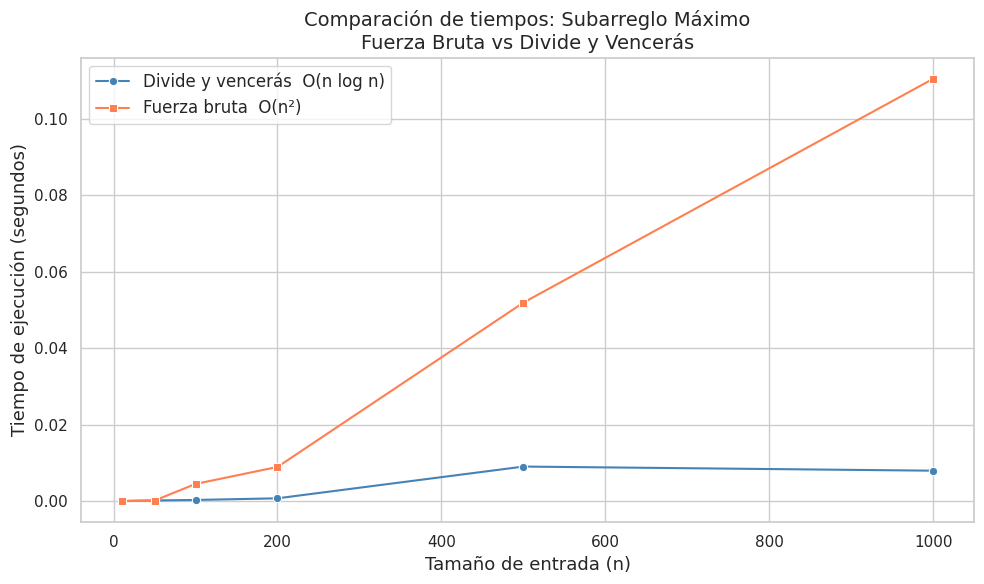

In [7]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.lineplot(x=datos, y=tiempos_dc, label='Divide y vencerás  O(n log n)', marker='o', color='steelblue')
sns.lineplot(x=datos, y=tiempos_fb, label='Fuerza bruta  O(n²)', marker='s', color='coral')

plt.xlabel('Tamaño de entrada (n)', fontsize=13)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=13)
plt.title('Comparación de tiempos: Subarreglo Máximo\nFuerza Bruta vs Divide y Vencerás', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('../resultados/grafica_subarreglo_maximo.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Conclusiones

**1. Crecimiento del tiempo de ejecución:**  
La gráfica evidencia que el algoritmo de **fuerza bruta** presenta un crecimiento cuadrático (O(n²)): su tiempo aumenta de forma notoria a medida que n crece, siendo especialmente visible a partir de n=500.  
El algoritmo de **divide y vencerás** crece de manera mucho más lenta (O(n log n)), manteniéndose prácticamente constante en la escala de la gráfica incluso para n=1000.

**2. Ventaja del paradigma divide y vencerás:**  
Para entradas pequeñas (n ≤ 50) ambos algoritmos son comparables. Sin embargo, a partir de n=200 la diferencia se vuelve apreciable, y para n=1000 la fuerza bruta puede ser decenas de veces más lenta, lo que confirma la superioridad asintótica de divide y vencerás.

**3. Trade-off: simplicidad vs rendimiento:**  
El algoritmo de fuerza bruta es más simple de implementar, pero no es escalable. Divide y vencerás requiere mayor complejidad (recursión + función auxiliar de cruce), pero ofrece rendimiento muy superior para entradas grandes.

**4. Importancia del caso base:**  
El caso base (arreglo de un solo elemento) es esencial para que la recursión termine correctamente. Sin él, el algoritmo caería en un ciclo infinito de llamadas recursivas.

**5. Conclusión general:**  
Para aplicaciones reales con arreglos grandes, divide y vencerás es la elección correcta. La fuerza bruta solo es justificable para verificación o arreglos muy pequeños.